# Case study 1: PNW heat dome with `its2s`

ITS counterfactual on Washington weekly injury deaths (`case_study1_data_clean.ipynb`), using **Prophet + XGBoost** (`prophet_xgb`). No covariates.

- **Data:** `../data/pnw_heatwave_injury_deaths_weekly.csv` (weekly, 2014–2021)
- **Intervention:** 2021-06-25
- **Holdout:** 3 weeks post-intervention (through week starting **2021-07-10**)


In [21]:
# load packages 
from pathlib import Path
import logging
import warnings
import pandas as pd
from IPython.display import Image, display
from its2s import run_single_its

# ignore warnings to clean up output
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)
for _name in ("cmdstanpy", "prophet", "stan", "its2s", "xgboost", "matplotlib"):
    logging.getLogger(_name).setLevel(logging.WARNING)

# setup
DATA_PATH = Path("../data/pnw_heatwave_injury_deaths_weekly.csv")
OUT_DIR = Path("../outputs")
INTERVENTION = "2021-06-25"
HOLDOUT_LAST_WEEK = pd.Timestamp("2021-07-10")
MODEL_NAME = "prophet_xgb"

# data and output directory
df = pd.read_csv(DATA_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# holdout and intervention parameterization
_intv = pd.Timestamp(INTERVENTION)
_holdout_days = (HOLDOUT_LAST_WEEK - _intv).days
_test_days = max(28, int(0.20 * (df["ds"] < _intv).sum()))

In [22]:
# run its2s

result = run_single_its(
    df,
    intervention_date=INTERVENTION,
    model_name=MODEL_NAME,
    config_overrides={
        "periods": {
            "split_method": "days",
            "test_days": _test_days,
            "holdout_days": _holdout_days,
        },
        "bootstrap": {"n_sim": 200, "block_length": 7},
    },
    output_dir=OUT_DIR,
    seed=42,
)

print(result.summary())

Model: prophet_xgb
Bootstrap: 200 simulations, 200 successful

Train metrics:
  RMSE=7.6122  MAE=6.0352  MAPE=6.31%  R2=0.7295
Test metrics:
  RMSE=10.5724  MAE=7.3061  MAPE=5.53%  R2=0.1858

Total ATE: 192.92 [180.14, 215.13]
Mean Daily ATE: 64.3082 [60.0478, 71.7111]
Holdout days: 3

Residual diagnostics:
  Mean=0.0800  Std=7.6219
  ACF(1)=0.087  ACF(7)=-0.030  ACF(14)=0.014
  Ljung-Box(10) p=0.0062
  Shapiro-Wilk p=0.4282


## Excess during 3-week holdout


In [23]:
# results 

row = result.excess_table.period_excess.iloc[0]

display(result.excess_table.daily_excess.round(1))

print(
    f"Total excess: {row['total_excess']:.0f} "
    f"[{row['excess_ci_lo']:.0f}, {row['excess_ci_hi']:.0f}]  |  "
    f"Percent excess vs expected: {row['excess_pct']:+.1f}%"
)

,date,observed,expected,expected_ci_lo,expected_ci_hi,excess,excess_ci_lo,excess_ci_hi,excess_pct,excess_pct_ci_lo,excess_pct_ci_hi
0,2021-06-26,150.0,116.2,104.5,123.0,33.8,27.0,45.5,29.1,23.3,39.2
1,2021-07-03,229.0,124.8,112.5,128.0,104.2,101.0,116.5,83.5,81.0,93.4
2,2021-07-10,178.0,123.1,113.6,132.5,54.9,45.5,64.4,44.6,37.0,52.3


Total excess: 193 [180, 215]  |  Percent excess vs expected: +53.0%


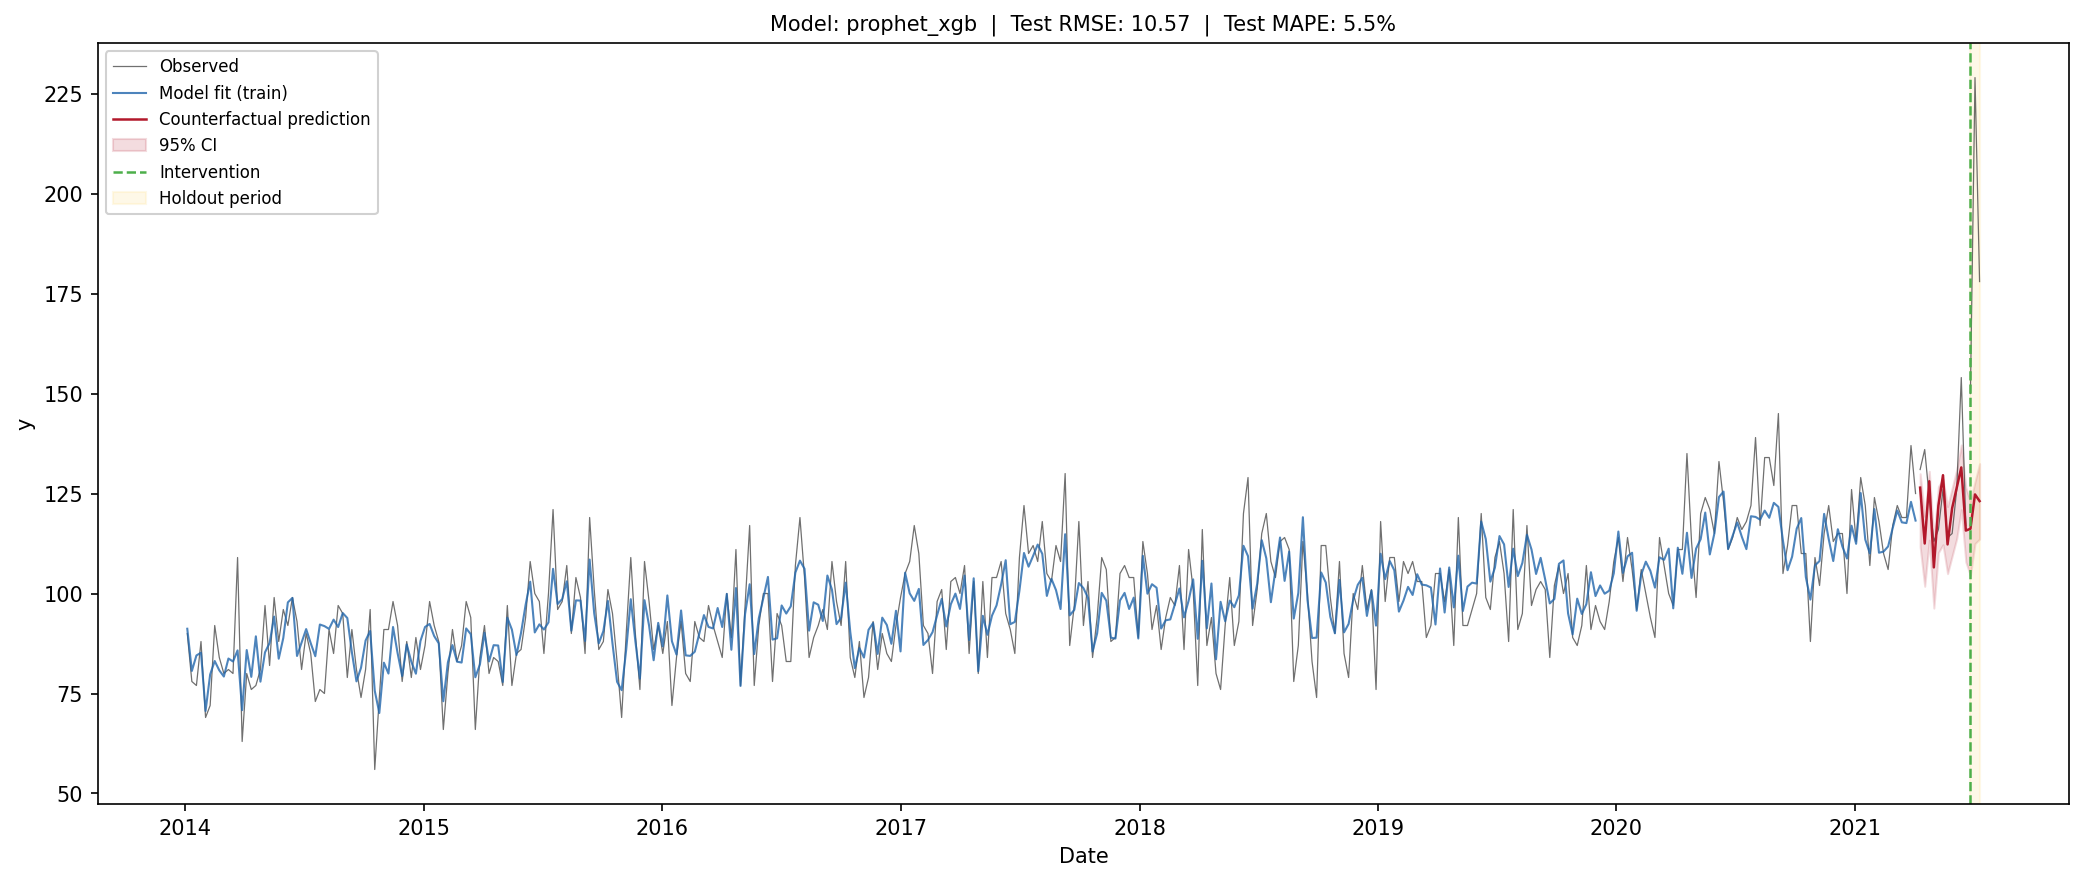

In [24]:
plot_path = OUT_DIR / f"{MODEL_NAME}_counterfactual.png"
display(Image(filename=str(plot_path)))